# Lab 4: Transfer Learning with a CNN

This notebook has been adapted from the [PyTorch tutorial on transfer learning](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html).
Similar to the original tutorial, this one will demonstrate two different variations of transfer learning.

As discussed in class, __[transfer learning](https://en.wikipedia.org/wiki/Transfer_learning)__ in machine learning is about utilizing an already-trained model for your specific problem or use case.

Large neural networks can take a significant amount of resources to train, in terms of long training time,
massive dataset size, and costly computer hardware. Given that, it's
no surprise that we would want to avoid training a model from scratch. This is where transfer learning comes in.

Transfer learning starts by taking a pre-trained neural network model that was trained to, say, predict which of
1000 possible types of animals is in an image. This model is then used/repurposed/recycled to, say, predict which of two animals
is in an image. Note that two types of animals that you want to perform classification on don't even need to be part of the original 1000 animals.

There are two types of transfer learning techniques we'll try. Technically, we will be using the exact same model architecture with the pre-trained parameters, but they will be different instances of the model. We will refer to them as Approach A and Approach B. The differences are:

-   **Approach A: Finetuning the ConvNet** - Start with the pre-trained model, change the final output layer to have only 2 units (or neurons), and then fine-tune or refit the model on our Ant and Bee images. All the parameter values can change. 
-   **Approach B: ConvNet as fixed feature extractor** - Again, start with the pre-trained model, change the final output layer to have only 2 units (or neurons), but this time only allow the parameter values in the (new) final layer to be modified.

You can open this notebook in either Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgeinitz/CS3120/blob/main/lab04_transfer_learning.ipynb)

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/sgeinitz/CS3120/blob/main/lab04_transfer_learning.ipynb)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory


# For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
%matplotlib inline

cudnn.benchmark = True
plt.ion()   # interactive mode

In [4]:
!git clone https://github.com/sgeinitz/CS3120.git

Cloning into 'CS3120'...
remote: Enumerating objects: 525, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 525 (delta 42), reused 36 (delta 32), pack-reused 476 (from 1)
Receiving objects: 100% (525/525), 46.32 MiB | 40.13 MiB/s, done.
Resolving deltas: 100% (59/59), done.


Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants
and bees. There are 75 validation images for each class. 

Trying to train a deep learning model from scratch with just one or two hundred images is not really possible. 
But, we're not going to train the deep learning model from scratch. Instead, we're going to use one that was already trained on millions 
of images to classify which of one-thousand (1000) possible categories the contents of the image falls into. 
We'll then going to fine tune the model for our specific problem of binary classification, namely: Bee or Ant (i.e, not Bee)).

Since we are using transfer learning, and *not* training the model from scratch, one or two hundred images is plenty.



NOTE: This is where `batch_size` is size (technically speaking, we're talking about the mini-batch size). Questions 3 and 4 below will ask you to come back 
and change this, but wait until you've run it one time with `batch_size=16` before changing it. 


In [5]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'CS3120/images/hymenoptera'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# check for a GPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
# check for an Apple MPS device
elif torch.backends.mps.is_available():
    device = torch.device("mps")
# otherwise use the CPU
else:
    device = torch.device("cpu")

# print out which device is being used
print(f"Using device: {device}")

Using device: cpu


Examine a few Images
======================

Let\'s visualize a few training images so as to understand the data
augmentations.

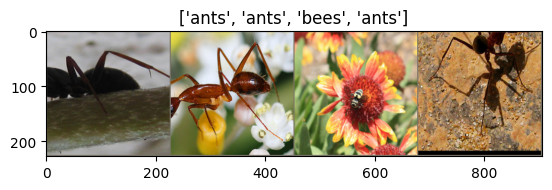

In [6]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

Training the model
==================

Now, let\'s write a general function to train a model. 

Notice that in addition to using mini-batches, there is another so-called _trick_ we're using. Namely, the use 
of a __scheduler__ to modify the learning rate over time. 

In the following, parameter `scheduler` is a LR scheduler object from
`torch.optim.lr_scheduler`. Right now it is only a a parameter in the `train_model` function, but you will see 
it declared/instantiated later on in this notebook. 


In [16]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    b_losses = {'train':[], 'val':[]}
    e_losses = {'train':[], 'val':[]}

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                    b_losses[phase].append(loss.item())

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]

                # print loss and accuraacy every 4 epochs
                if epoch % 4 == 0:
                    print('-' * 10)
                    print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                # save loss for plotting later on
                e_losses[phase].append(epoch_loss)

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model, e_losses, b_losses

Visualizing the model predictions
=================================

Generic function to display predictions for a few images


In [18]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

Approach A: Finetuning the ConvNet
======================

Load a pretrained model and reset final fully connected layer.

This is also where we create instances of the `optimizer` and `scheduler` objects, both of which are then passed into 
the `train_model` function as parameters. 

In [19]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features

# Here the size of each output sample is set to 2.
# In general, this could be written as ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Train and evaluate
==================

This will take 1-2 minutes on a GPU, or around 20-25 minutes with a CPU. 


In [20]:
model_ft, epoch_losses, batch_losses = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5792 Acc: 0.7008
----------
val Loss: 0.3419 Acc: 0.8824

Epoch 1/24

Epoch 2/24

Epoch 3/24

Epoch 4/24
----------
train Loss: 0.5171 Acc: 0.8074
----------
val Loss: 0.2304 Acc: 0.9085

Epoch 5/24

Epoch 6/24

Epoch 7/24

Epoch 8/24
----------
train Loss: 0.2548 Acc: 0.8852
----------
val Loss: 0.4282 Acc: 0.8758

Epoch 9/24

Epoch 10/24

Epoch 11/24

Epoch 12/24
----------
train Loss: 0.3757 Acc: 0.8484
----------
val Loss: 0.2375 Acc: 0.9216

Epoch 13/24

Epoch 14/24

Epoch 15/24

Epoch 16/24
----------
train Loss: 0.3172 Acc: 0.8852
----------
val Loss: 0.1982 Acc: 0.9346

Epoch 17/24

Epoch 18/24

Epoch 19/24

Epoch 20/24
----------
train Loss: 0.2890 Acc: 0.8811
----------
val Loss: 0.2228 Acc: 0.9216

Epoch 21/24

Epoch 22/24

Epoch 23/24

Epoch 24/24
----------
train Loss: 0.2833 Acc: 0.8852
----------
val Loss: 0.2967 Acc: 0.9020

Training complete in 17m 27s
Best val Acc: 0.934641


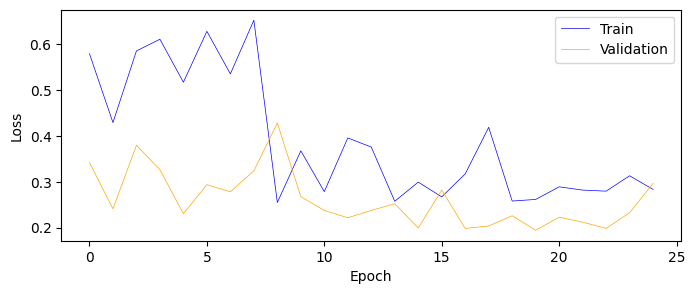

In [21]:
# plot the loss curves
plt.figure(figsize=(8, 3))
plt.plot(range(len(epoch_losses['train'])), epoch_losses['train'], c='blue', linewidth=0.5)
plt.plot(range(len(epoch_losses['val'])), epoch_losses['val'], c='orange', linewidth=0.5)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(('Train','Validation'))

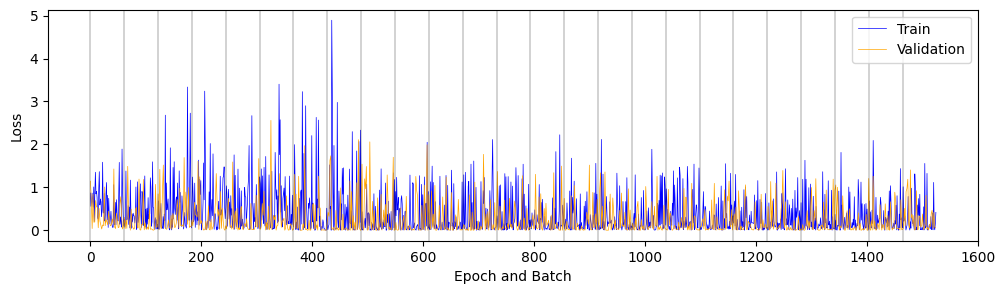

In [22]:
# plot the loss curves for each (mini) batch
plt.figure(figsize=(12, 3))
val_ticks = [(i)*len(batch_losses['train'])/len(batch_losses['val']) for i in range(len(batch_losses['val']))]
plt.plot(range(len(batch_losses['train'])), batch_losses['train'], c='blue', linewidth=0.5)
plt.plot(val_ticks, batch_losses['val'], c='orange', linewidth=0.5)
for i in range(25):
    plt.axvline(x=i*len(batch_losses['train'])/25, c='black', lw=0.25)
plt.ylabel('Loss')
plt.xlabel('Epoch and Batch')
plt.legend(('Train','Validation'))

In [ ]:
visualize_model(model_ft)

Approach B: ConvNet as fixed feature extractor
==================================

Here, we need to freeze all the network except the final layer. We need
to set `requires_grad = False` to freeze the parameters so that the
gradients are not computed in `backward()`.

You can read more about this in the documentation
[here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward).


In [10]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s] 


Train and evaluate
==================

Now use `train_model` again, but with the above model object, which has frozen all the parameters except for those in the final layer. 

***
### Q1: Will this run faster or slower than the earlier training run? Explain why or why not?

It will run faster than the earlier training run. This is because since all of the parameters have been frozen. From what I learned this is because the framework doesn't bother in computing the frozen layers so it saves the time in having to compute each one. Mainly just going through each layer to see if it is frozen or not and moving on until it find the ones that aren't. Those are computed and that would be why it would be faster than the earlier training run. 
***

In [11]:
model_conv, epoch_losses, batch_losses = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5990 Acc: 0.6926
----------
val Loss: 0.2901 Acc: 0.8758

Epoch 1/24

Epoch 2/24

Epoch 3/24

Epoch 4/24
----------
train Loss: 0.3756 Acc: 0.8361
----------
val Loss: 0.2632 Acc: 0.9150

Epoch 5/24

Epoch 6/24

Epoch 7/24

Epoch 8/24
----------
train Loss: 0.4142 Acc: 0.8115
----------
val Loss: 0.2779 Acc: 0.8889

Epoch 9/24

Epoch 10/24

Epoch 11/24

Epoch 12/24
----------
train Loss: 0.3115 Acc: 0.8730
----------
val Loss: 0.2348 Acc: 0.9281

Epoch 13/24

Epoch 14/24

Epoch 15/24

Epoch 16/24
----------
train Loss: 0.3757 Acc: 0.8443
----------
val Loss: 0.2117 Acc: 0.9216

Epoch 17/24

Epoch 18/24

Epoch 19/24

Epoch 20/24
----------
train Loss: 0.3214 Acc: 0.8361
----------
val Loss: 0.1929 Acc: 0.9150

Epoch 21/24

Epoch 22/24

Epoch 23/24

Epoch 24/24
----------
train Loss: 0.3463 Acc: 0.8238
----------
val Loss: 0.2384 Acc: 0.9281

Training complete in 9m 6s
Best val Acc: 0.941176


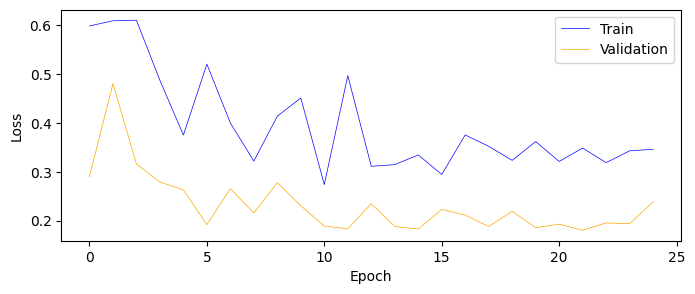

In [13]:
# plot the loss curves
plt.figure(figsize=(8, 3))
plt.plot(range(len(epoch_losses['train'])), epoch_losses['train'], c='blue', linewidth=0.5)
plt.plot(range(len(epoch_losses['val'])), epoch_losses['val'], c='orange', linewidth=0.5)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(('Train','Validation'))

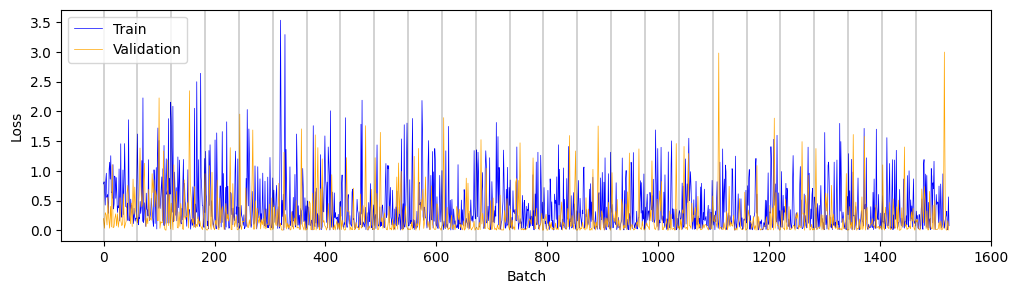

In [14]:
# plot the loss curves for each (mini) batch
plt.figure(figsize=(12, 3))
val_ticks = [(i)*len(batch_losses['train'])/len(batch_losses['val']) for i in range(len(batch_losses['val']))]
plt.plot(range(len(batch_losses['train'])), batch_losses['train'], c='blue', linewidth=0.5)
plt.plot(val_ticks, batch_losses['val'], c='orange', linewidth=0.5)
for i in range(25):
    plt.axvline(x=i*len(batch_losses['train'])/25, c='black', lw=0.25)
plt.ylabel('Loss')
plt.xlabel('Batch')
plt.legend(('Train','Validation'))

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

***
### Q2: Which of the two approaches worked best (in terms of validation accuracy)? Approach A or Approach B? Explain why you think this might be?

Approach A worked best because it was adapted to the data that was given rather than only on the final layer. All of the layers are fine tuned to the dataset that is provided, rather than only working with the final layers as the rest are frozen in approach B. Approach A goes through all of the layers and adapts to the data rather than just the last layers. Though it might take a bit longer it is more accurate as it acutually works with all of the data. 
***

***
### Q3: Change the batch size from 16 to 32 and then re-run both model training runs. How does this change the training and performance?

When changing it from 16 to 32, the performance for approach A doubled in the execution time. It went from 11 minutes with 16 in the batch to about 25 minutes in the 32 sized batch. The training and accuracy stayed around the same. For approach B the execution time stayed around the same time at around 5 minutes for both 16 and 32 as the batch size. Overall, it makes sense for approach A to be slower because it has more layers to go through compared to before, so double the batch size also means double the execution time. For approach B, since it doesn't worry about all the layers it didn't really seem to matter for it. 
***




***
### Q4: Change the batch size from 32 to 4 and then re-run both model training runs. How does this change the training and performance?  Also comment on whether there are now more or less mini-batches. 

For approach A it took around 17 minutes to execute the batch with a smaller amount. The accuracy also was lower compared to the batch with 32, for 32 the accuracy was around 0.94 while for a batch of 4 it was arround 0.90. The time also increased to 17 minutes, for 16 it was 11 minutes and for 32 it was the 17 minutes. I thought it would be less time but it took more than the size 16 for some reason. For approach B the accuracy was around the same with only a 0.01 difference between the two. When it comes to the performace and the run time it increased from 5 minutes to 9 minutes for it to work through the 4 batches compared to the 32. I thought it would take less time since the size would be smaller. There were also more mini-batches when changing to 4 rather than 32. 
***

***
### Q5: Look at the loss curves when the batch size was 32 and compare them to when the batch size of 4. For which batch size were the loss curves more bumpy or jagged? Explain why this is?  

It is interesting to see the graphs for the loss curves for a batch size of 4. The batches graph has a lot more lines and peaks on it, they are more jagged. This is because there are a lot more mini batches when the sizes of the batch is smaller. Intead of the values being in the hundreds with the size 32, they move up to almost 1,600 The loss graph themselves are also a bit more jagged, while the graphs for the batch size of 32, the curves where a bit bumpy but they still have a smoother or clearer line. They still sort of held a linear shape or at least a curve. After doing a bit of research on this and asking Claude to explain it a bit more, it explained how the smaller size batch has high varience gradients, meaning it jumps around a lot during the steps, leaving a more jagged and jumpy graph. While the larger size batch has a lower varience gradient and leaves a slightly smoother graph and is more consistent in the direction that it goes. 
***

Inference on one Images
==========================

Use the trained model to make predictions on custom images and visualize
the predicted class labels along with the images.


In [25]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

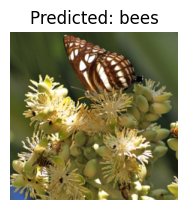

In [26]:
visualize_model_predictions(
    model_conv,
    img_path='CS3120/images/hymenoptera/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()